<a href="https://colab.research.google.com/github/Gund2005/CodeAlpha_Flashcard_/blob/main/CodeAlpha_TASK2_TASK3_EDA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 2: EXPLORATORY DATA ANALYSIS

Please upload 'sales_data.csv' file to Colab
Using sample data for demonstration

--- First 5 Rows ---
        Date Product Region  Sales  Profit
0 2024-01-01   Mouse   East    618     266
1 2024-01-02  Laptop  North    620     198
2 2024-01-03   Mouse  South    355     149
3 2024-01-04  Laptop  North    755     103
4 2024-01-05   Mouse   East    949      45

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     100 non-null    datetime64[ns]
 1   Product  100 non-null    object        
 2   Region   100 non-null    object        
 3   Sales    100 non-null    int64         
 4   Profit   100 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 4.0+ KB
None

--- Statistical Summary ---
                      Date       Sales      Profit
count     

/tmp/ipykernel_825/1698912816.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette='Blues_d')


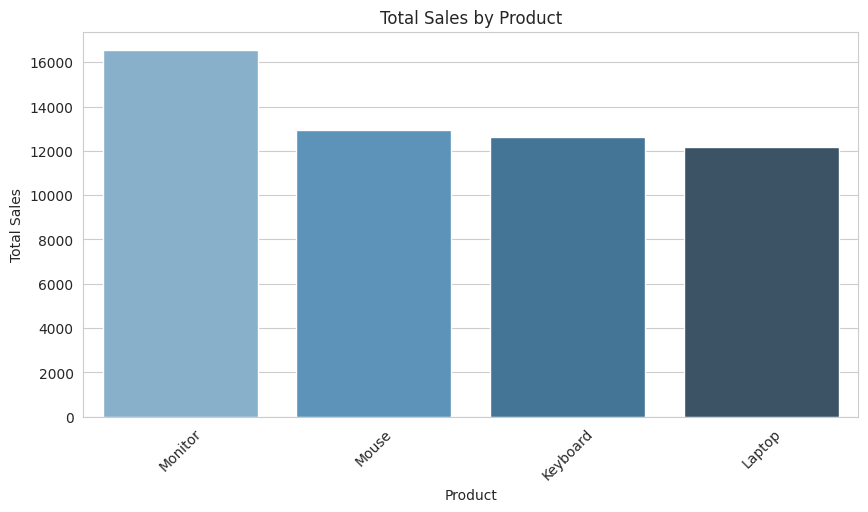


--- Profit by Region ---
Region
South    5158
North    3604
East     3151
West     2643
Name: Profit, dtype: int64


/tmp/ipykernel_825/1698912816.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='Greens_d')


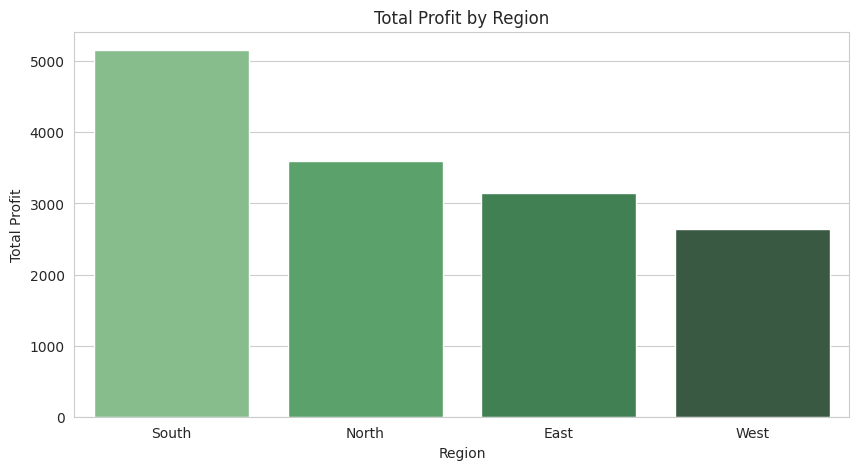

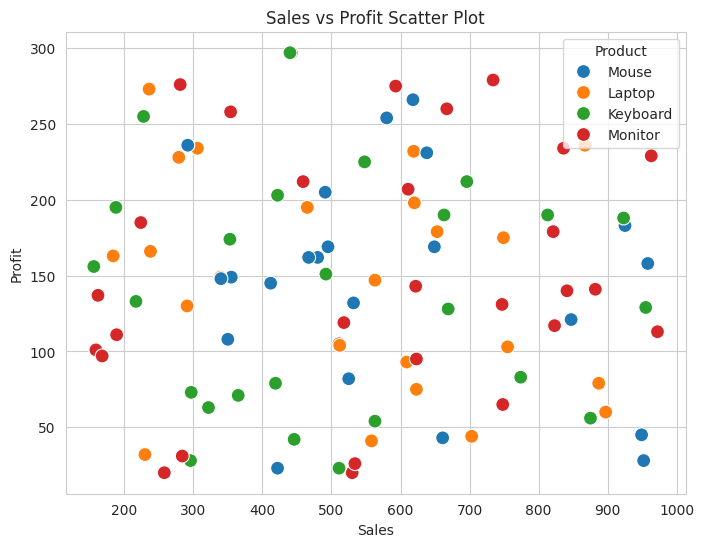


Correlation between Sales and Profit: -0.033

--- Monthly Sales Trend ---
Month
April        5196
February    16395
January     16720
March       15997
Name: Sales, dtype: int64

ANALYSIS COMPLETED SUCCESSFULLY


In [1]:
# ============================================
# TASK 2: EDA - Exploratory Data Analysis
# TASK 3: Basic Sales and Profit Analysis
# Dataset: Sample Sales Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better graphs
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("TASK 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Load Dataset
# Note: Upload your 'sales_data.csv' file in Colab first
try:
    df = pd.read_csv('sales_data.csv')
    print("\nDataset loaded successfully!")
except FileNotFoundError:
    print("\nPlease upload 'sales_data.csv' file to Colab")
    # For demo, creating sample data
    data = {
        'Date': pd.date_range(start='2024-01-01', periods=100, freq='D'),
        'Product': np.random.choice(['Laptop', 'Mouse', 'Keyboard', 'Monitor'], 100),
        'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
        'Sales': np.random.randint(100, 1000, 100),
        'Profit': np.random.randint(20, 300, 100)
    }
    df = pd.DataFrame(data)
    print("Using sample data for demonstration")

# 2. Display basic info
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Data Cleaning
df.dropna(inplace=True)
print("\nMissing values removed. Shape of dataset:", df.shape)

print("\n" + "="*60)
print("TASK 3: SALES AND PROFIT ANALYSIS")
print("="*60)

# 1. Total Sales and Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {(total_profit/total_sales)*100:.2f}%")

# 2. Sales by Product
sales_by_product = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print("\n--- Sales by Product ---")
print(sales_by_product)

plt.figure(figsize=(10,5))
sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette='Blues_d')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# 3. Profit by Region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\n--- Profit by Region ---")
print(profit_by_region)

plt.figure(figsize=(10,5))
sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='Greens_d')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

# 4. Sales vs Profit Correlation
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Product', s=100)
plt.title('Sales vs Profit Scatter Plot')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

correlation = df['Sales'].corr(df['Profit'])
print(f"\nCorrelation between Sales and Profit: {correlation:.3f}")

# 5. Monthly Trend if Date column exists
if 'Date' in df.columns:
    df['Month'] = pd.to_datetime(df['Date']).dt.month_name()
    monthly_sales = df.groupby('Month')['Sales'].sum()
    print("\n--- Monthly Sales Trend ---")
    print(monthly_sales)

print("\n" + "="*60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("="*60)